In [2]:

import json
import re
from itertools import product
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["figure.figsize"] = (8, 5)

BASE_DIR = Path(r"D:\бгуир\DSMABY\Credit Scoring Model")
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR = BASE_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
METRICS_DIR = REPORTS_DIR / "metrics"

TARGET_COLUMN = "default_payment_next_month"
ID_COLUMN = "id"
RANDOM_STATE = 42
TEST_SIZE = 0.15
N_SPLITS = 5

for path in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, METRICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Папки проекта готовы.")
print("Базовая директория:", BASE_DIR)

Папки проекта готовы.
Базовая директория: D:\бгуир\DSMABY\Credit Scoring Model


## 1. Загрузка и очистка данных

In [3]:
ALLOWED_RAW_FILENAMES = [
    "default_of_credit_card_clients.xls",
    "default_of_credit_card_clients.xlsx",
    "default_of_credit_card_clients.csv",
    "uci_credit_card.csv",
    "credit_scoring.csv",
]

def clean_column_name(column_name: str) -> str:
    cleaned = str(column_name).strip().lower()
    cleaned = cleaned.replace("%", "pct")
    cleaned = re.sub(r"[^a-z0-9]+", "_", cleaned)
    cleaned = re.sub(r"_+", "_", cleaned).strip("_")
    return cleaned

def detect_source_file() -> Path:
    for filename in ALLOWED_RAW_FILENAMES:
        candidate = RAW_DIR / filename
        if candidate.exists():
            return candidate

    for file_path in RAW_DIR.iterdir():
        if file_path.suffix.lower() in {".csv", ".xls", ".xlsx"}:
            return file_path

    raise FileNotFoundError(
        f"Не найден датасет в папке {RAW_DIR}. "
        "Положи туда CSV/XLS/XLSX-файл."
    )

def read_tabular_file(file_path: Path) -> pd.DataFrame:
    suffix = file_path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(file_path)

    if suffix == ".xlsx":
        return pd.read_excel(file_path, engine="openpyxl")

    if suffix == ".xls":
        try:
            return pd.read_excel(file_path, engine="xlrd")
        except Exception:
            return pd.read_excel(file_path)

    raise ValueError(f"Неподдерживаемый формат файла: {file_path.suffix}")

def normalize_target_name(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {}
    for column in df.columns:
        if column in {
            "default_payment_next_month",
            "default_payment_next_month_y",
            "default_payment_next_month_1_yes_0_no",
            "default_payment_next_month_default",
        }:
            rename_map[column] = TARGET_COLUMN
    return df.rename(columns=rename_map)

def drop_duplicate_header_row(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df

    first_row = df.iloc[0].astype(str).tolist()
    overlap = sum(clean_column_name(value) in set(df.columns) for value in first_row)

    if overlap >= max(3, int(len(df.columns) * 0.30)):
        return df.iloc[1:].reset_index(drop=True)

    return df

source_file = detect_source_file()
print("Источник:", source_file)

df = read_tabular_file(source_file)
original_shape = df.shape
original_columns = list(df.columns)

df.columns = [clean_column_name(column) for column in df.columns]
df = normalize_target_name(df)

if TARGET_COLUMN not in df.columns and source_file.suffix.lower() in {".xls", ".xlsx"}:
    df = pd.read_excel(source_file, header=1)
    df.columns = [clean_column_name(column) for column in df.columns]
    df = normalize_target_name(df)

df = drop_duplicate_header_row(df)

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Не найдена целевая колонка. Текущие колонки: {list(df.columns)}"
    )

if ID_COLUMN in df.columns:
    df = df.drop(columns=[ID_COLUMN])

df = df.dropna(subset=[TARGET_COLUMN]).copy()
df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
df = df.dropna(subset=[TARGET_COLUMN]).copy()
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

for column in df.columns:
    if column == TARGET_COLUMN:
        continue
    df[column] = pd.to_numeric(df[column], errors="ignore")

categorical_features = [column for column in ["sex", "education", "marriage"] if column in df.columns]
numeric_features = [column for column in df.columns if column not in categorical_features + [TARGET_COLUMN]]

df.to_csv(PROCESSED_DIR / "cleaned_credit_scoring.csv", index=False)

metadata = {
    "source_file": str(source_file),
    "original_shape": list(original_shape),
    "cleaned_shape": list(df.shape),
    "original_columns": original_columns,
    "cleaned_columns": list(df.columns),
    "target_column": TARGET_COLUMN,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "target_distribution": {
        "0": int((df[TARGET_COLUMN] == 0).sum()),
        "1": int((df[TARGET_COLUMN] == 1).sum()),
    },
}

(PROCESSED_DIR / "dataset_metadata.json").write_text(
    json.dumps(metadata, indent=4, ensure_ascii=False),
    encoding="utf-8",
)

print("Данные очищены.")
print("Форма датасета:", df.shape)
display(df.head())

Источник: D:\бгуир\DSMABY\Credit Scoring Model\data\raw\default_of_credit_card_clients.xls
Данные очищены.
Форма датасета: (30000, 24)


C:\Users\user\AppData\Local\Temp\ipykernel_4320\3022072911.py:105: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[column] = pd.to_numeric(df[column], errors="ignore")


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Проверка дисбаланса классов

In [4]:
target_distribution = df[TARGET_COLUMN].value_counts().sort_index()
target_ratio = df[TARGET_COLUMN].value_counts(normalize=True).sort_index()

imbalance_df = pd.DataFrame({
    "count": target_distribution,
    "ratio": target_ratio.round(4),
})

display(imbalance_df)

minority_ratio = float(target_ratio.min())
majority_ratio = float(target_ratio.max())

print(f"Доля меньшего класса: {minority_ratio:.4f}")
print(f"Доля большего класса: {majority_ratio:.4f}")

if minority_ratio < 0.35:
    print("Вывод: классы несбалансированы, учитываем это в моделировании.")
else:
    print("Вывод: сильного дисбаланса нет.")

,count,ratio
default_payment_next_month,,
0,23364,0.7788
1,6636,0.2212


Доля меньшего класса: 0.2212
Доля большего класса: 0.7788
Вывод: классы несбалансированы, учитываем это в моделировании.


## 3. Train/Test split

In [5]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_full_df = X_train_full.copy()
train_full_df[TARGET_COLUMN] = y_train_full.values

test_df = X_test.copy()
test_df[TARGET_COLUMN] = y_test.values

train_full_df.to_csv(INTERIM_DIR / "train_full.csv", index=False)
test_df.to_csv(INTERIM_DIR / "test.csv", index=False)

split_summary = {
    "train_full_shape": list(train_full_df.shape),
    "test_shape": list(test_df.shape),
    "train_full_target_rate": float(train_full_df[TARGET_COLUMN].mean()),
    "test_target_rate": float(test_df[TARGET_COLUMN].mean()),
}

(PROCESSED_DIR / "split_summary.json").write_text(
    json.dumps(split_summary, indent=4, ensure_ascii=False),
    encoding="utf-8",
)

print("Размер train_full:", train_full_df.shape)
print("Размер test:", test_df.shape)
print("Доля дефолтов train_full:", round(train_full_df[TARGET_COLUMN].mean(), 4))
print("Доля дефолтов test:", round(test_df[TARGET_COLUMN].mean(), 4))

Размер train_full: (25500, 24)
Размер test: (4500, 24)
Доля дефолтов train_full: 0.2212
Доля дефолтов test: 0.2211


## 4. EDA

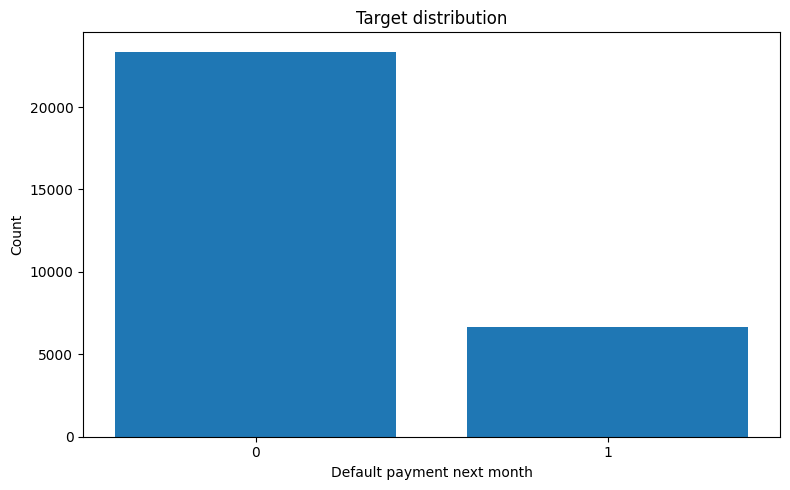

In [6]:
def save_current_figure(file_name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

eda_summary_lines = [
    "# EDA summary",
    f"Rows: {df.shape[0]}",
    f"Columns: {df.shape[1]}",
    f"Target mean: {df[TARGET_COLUMN].mean():.4f}",
    "",
    "Missing values:",
    df.isna().sum().to_string(),
    "",
    "Describe:",
    df.describe(include="all").to_string(),
]

(PROCESSED_DIR / "eda_summary.txt").write_text(
    "\n".join(eda_summary_lines),
    encoding="utf-8",
)

target_counts = df[TARGET_COLUMN].value_counts().sort_index()
plt.figure()
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Target distribution")
plt.xlabel("Default payment next month")
plt.ylabel("Count")
save_current_figure("01_target_distribution.png")

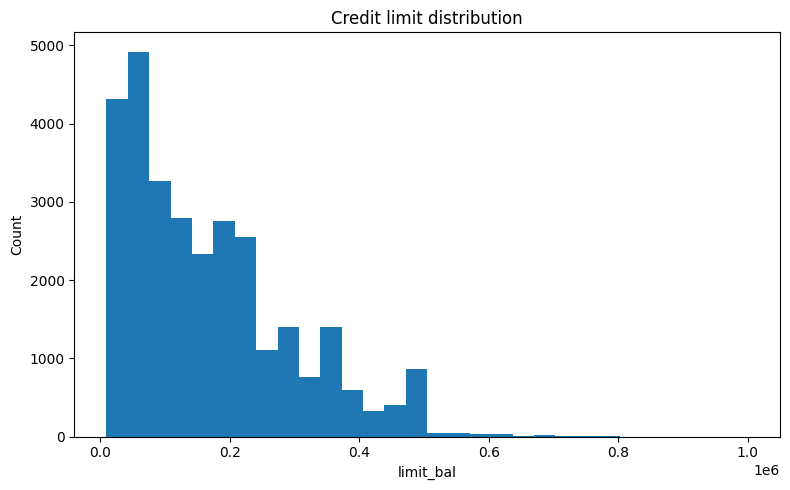

In [7]:
if "limit_bal" in df.columns:
    plt.figure()
    plt.hist(df["limit_bal"], bins=30)
    plt.title("Credit limit distribution")
    plt.xlabel("limit_bal")
    plt.ylabel("Count")
    save_current_figure("02_limit_bal_distribution.png")

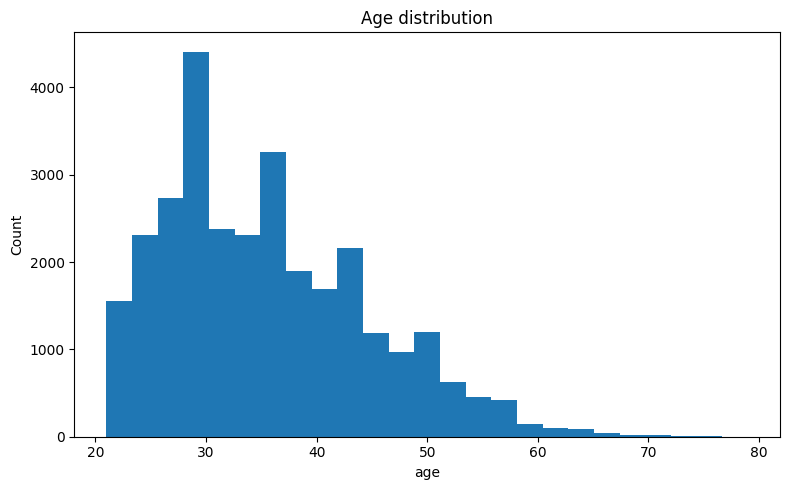

In [8]:
if "age" in df.columns:
    plt.figure()
    plt.hist(df["age"], bins=25)
    plt.title("Age distribution")
    plt.xlabel("age")
    plt.ylabel("Count")
    save_current_figure("03_age_distribution.png")

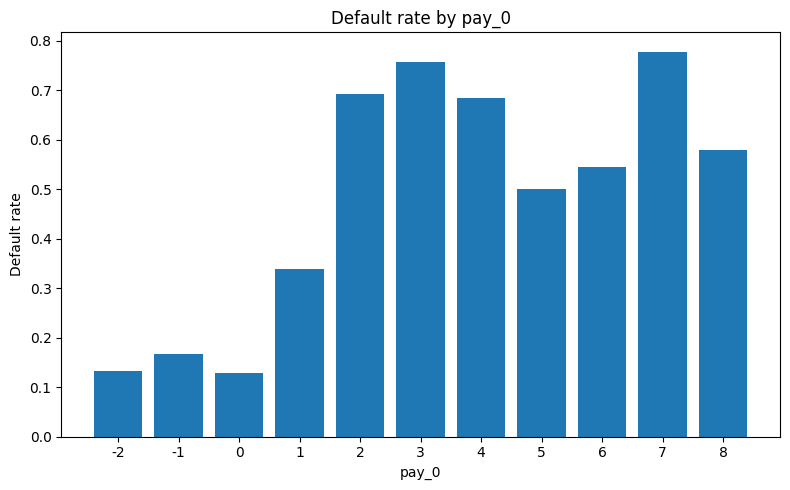

In [9]:
if "pay_0" in df.columns:
    pay0_default_rate = df.groupby("pay_0")[TARGET_COLUMN].mean().sort_index()
    plt.figure()
    plt.bar(pay0_default_rate.index.astype(str), pay0_default_rate.values)
    plt.title("Default rate by pay_0")
    plt.xlabel("pay_0")
    plt.ylabel("Default rate")
    save_current_figure("04_default_rate_by_pay0.png")

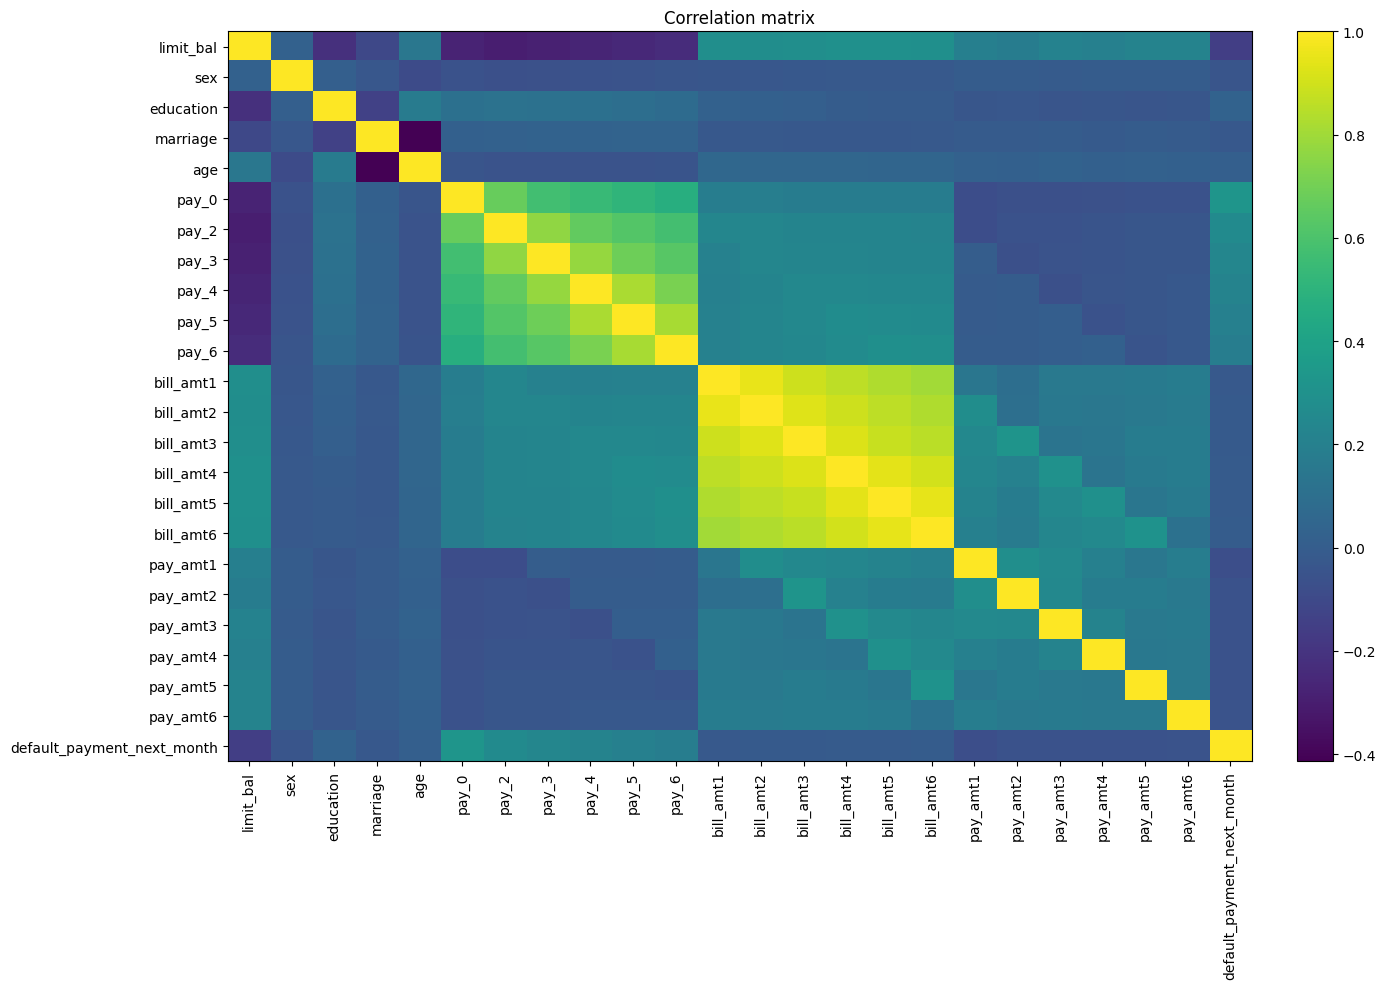

In [10]:
corr = df.select_dtypes(include=["number"]).corr(numeric_only=True)

plt.figure(figsize=(14, 10))
image = plt.imshow(corr, aspect="auto")
plt.colorbar(image, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
save_current_figure("05_correlation_matrix.png")

## 5. Общие функции и настройки cross-validation

In [11]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

def find_best_threshold(y_true: pd.Series, y_proba: np.ndarray) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    if len(thresholds) == 0:
        return 0.5

    f1_scores = (2 * precision[:-1] * recall[:-1]) / np.clip(
        precision[:-1] + recall[:-1],
        a_min=1e-12,
        a_max=None,
    )

    best_index = int(np.argmax(f1_scores))
    return float(thresholds[best_index])

def calculate_metrics(y_true: pd.Series, y_proba: np.ndarray, threshold: float) -> dict:
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def save_eval_plots(y_true: pd.Series, y_proba: np.ndarray, threshold: float, prefix: str) -> None:
    plt.figure(figsize=(6, 6))
    RocCurveDisplay.from_predictions(y_true, y_proba)
    plt.title(f"ROC curve - {prefix}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{prefix}_roc_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(6, 6))
    PrecisionRecallDisplay.from_predictions(y_true, y_proba)
    plt.title(f"PR curve - {prefix}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{prefix}_pr_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    y_pred = (y_proba >= threshold).astype(int)
    plt.figure(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title(f"Confusion matrix - {prefix}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{prefix}_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

## 6. Baseline model + cross-validation

In [12]:
def build_baseline_pipeline(
    numeric_features: list[str],
    categorical_features: list[str],
) -> Pipeline:
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ],
        n_jobs=-1,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    solver="liblinear",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    return pipeline

baseline_pipeline = build_baseline_pipeline(numeric_features, categorical_features)

baseline_cv_results = cross_validate(
    estimator=baseline_pipeline,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

baseline_cv_summary = {
    metric: float(np.mean(values))
    for metric, values in baseline_cv_results.items()
    if metric.startswith("test_")
}

print("Baseline CV summary:")
print(json.dumps(baseline_cv_summary, indent=4, ensure_ascii=False))

Baseline CV summary:
{
    "test_roc_auc": 0.7269072088358051,
    "test_pr_auc": 0.5021859283804861,
    "test_f1": 0.47906120374551087,
    "test_precision": 0.37917878755222595,
    "test_recall": 0.6507649711977586
}


Baseline OOF threshold: 0.588107
Baseline test metrics:
{
    "threshold": 0.5881070511928788,
    "accuracy": 0.7944444444444444,
    "roc_auc": 0.7122138509953476,
    "pr_auc": 0.4985275204552639,
    "precision": 0.5422705314009661,
    "recall": 0.45125628140703516,
    "f1": 0.4925946242457488,
    "tn": 3126,
    "fp": 379,
    "fn": 546,
    "tp": 449
}


<Figure size 600x600 with 0 Axes>

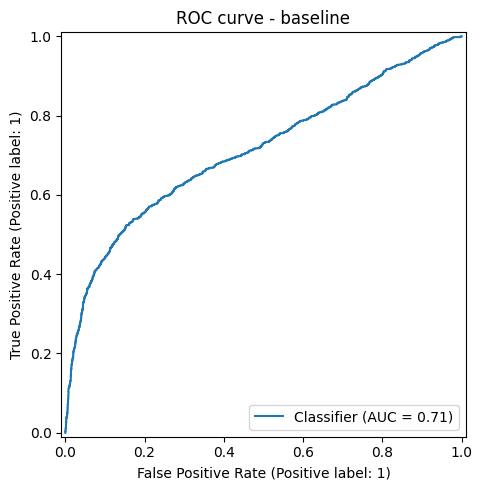

<Figure size 600x600 with 0 Axes>

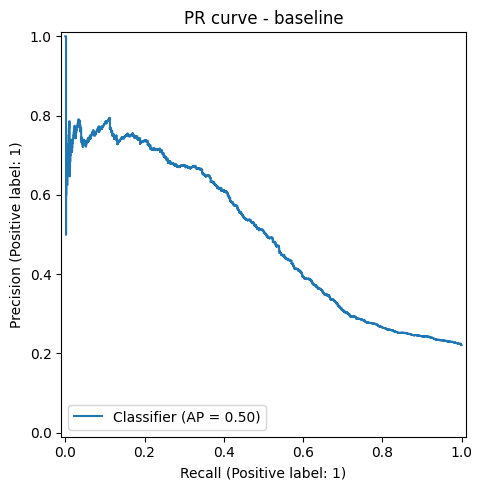

<Figure size 600x600 with 0 Axes>

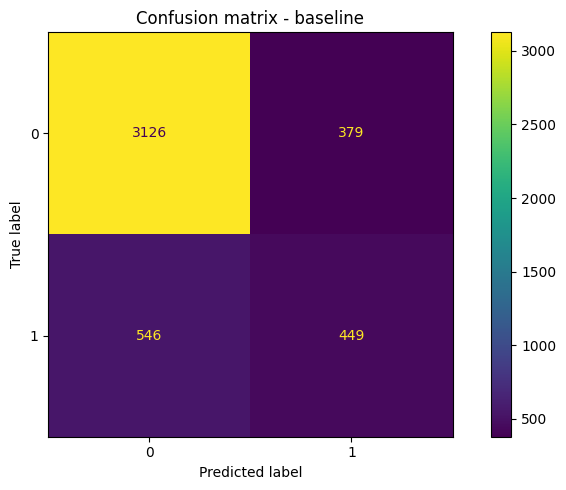

In [13]:
baseline_oof_proba = cross_val_predict(
    estimator=baseline_pipeline,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

baseline_threshold = find_best_threshold(y_train_full, baseline_oof_proba)
print("Baseline OOF threshold:", round(baseline_threshold, 6))

baseline_pipeline.fit(X_train_full, y_train_full)
baseline_test_proba = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_test_metrics = calculate_metrics(y_test, baseline_test_proba, baseline_threshold)

joblib.dump(baseline_pipeline, MODELS_DIR / "baseline_logistic_regression.joblib")

print("Baseline test metrics:")
print(json.dumps(baseline_test_metrics, indent=4, ensure_ascii=False))

save_eval_plots(y_test, baseline_test_proba, baseline_threshold, "baseline")

## 7. CatBoost + cross-validation + hyperparameter tuning

Настройки:
- `thread_count=-1` — все потоки CPU;
- `verbose=100` — лог каждые 100 итераций;
- `auto_class_weights="Balanced"` — учёт дисбаланса;
- отбор лучшей конфигурации по `PR-AUC`.

In [14]:
def prepare_catboost_frame(
    X_frame: pd.DataFrame,
    categorical_features: list[str],
) -> pd.DataFrame:
    frame = X_frame.copy()

    for column in categorical_features:
        if column in frame.columns:
            frame[column] = frame[column].astype("string").fillna("missing")

    return frame

X_train_full_cb = prepare_catboost_frame(X_train_full, categorical_features)
X_test_cb = prepare_catboost_frame(X_test, categorical_features)

In [15]:
def run_catboost_cv(
    X_data: pd.DataFrame,
    y_data: pd.Series,
    categorical_features: list[str],
    cv: StratifiedKFold,
    params: dict,
) -> tuple[list[dict], np.ndarray]:
    fold_metrics = []
    oof_proba = np.zeros(len(X_data), dtype=float)

    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_data, y_data), start=1):
        X_train_fold = X_data.iloc[train_idx].copy()
        X_valid_fold = X_data.iloc[valid_idx].copy()
        y_train_fold = y_data.iloc[train_idx]
        y_valid_fold = y_data.iloc[valid_idx]

        model = CatBoostClassifier(
            **params,
            auto_class_weights="Balanced",
            loss_function="Logloss",
            eval_metric="PRAUC",
            random_seed=RANDOM_STATE,
            thread_count=-1,
            verbose=100,
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            cat_features=categorical_features,
            eval_set=(X_valid_fold, y_valid_fold),
            use_best_model=True,
            early_stopping_rounds=100,
        )

        valid_proba = model.predict_proba(X_valid_fold)[:, 1]
        oof_proba[valid_idx] = valid_proba

        fold_result = {
            "fold": fold_idx,
            "roc_auc": float(roc_auc_score(y_valid_fold, valid_proba)),
            "pr_auc": float(average_precision_score(y_valid_fold, valid_proba)),
        }
        fold_metrics.append(fold_result)

    return fold_metrics, oof_proba

In [16]:
param_grid = {
    "depth": [4, 6],
    "learning_rate": [0.03, 0.05],
    "l2_leaf_reg": [3, 5],
    "iterations": [400, 700],
}

param_combinations = list(product(
    param_grid["depth"],
    param_grid["learning_rate"],
    param_grid["l2_leaf_reg"],
    param_grid["iterations"],
))

print("Количество комбинаций:", len(param_combinations))

Количество комбинаций: 16


In [17]:
tuning_rows = []
best_params = None
best_cv_pr_auc = -1.0
best_oof_proba = None

for depth, learning_rate, l2_leaf_reg, iterations in param_combinations:
    params = {
        "depth": depth,
        "learning_rate": learning_rate,
        "l2_leaf_reg": l2_leaf_reg,
        "iterations": iterations,
    }

    print("=" * 100)
    print(f"Проверяем параметры: {params}")

    fold_metrics, oof_proba = run_catboost_cv(
        X_data=X_train_full_cb,
        y_data=y_train_full.reset_index(drop=True),
        categorical_features=categorical_features,
        cv=cv,
        params=params,
    )

    mean_roc_auc = float(np.mean([item["roc_auc"] for item in fold_metrics]))
    mean_pr_auc = float(np.mean([item["pr_auc"] for item in fold_metrics]))

    row = {
        "depth": depth,
        "learning_rate": learning_rate,
        "l2_leaf_reg": l2_leaf_reg,
        "iterations": iterations,
        "cv_roc_auc_mean": mean_roc_auc,
        "cv_pr_auc_mean": mean_pr_auc,
    }
    tuning_rows.append(row)

    print("CV mean ROC-AUC:", round(mean_roc_auc, 6))
    print("CV mean PR-AUC:", round(mean_pr_auc, 6))

    if mean_pr_auc > best_cv_pr_auc:
        best_cv_pr_auc = mean_pr_auc
        best_params = params
        best_oof_proba = oof_proba.copy()

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    by=["cv_pr_auc_mean", "cv_roc_auc_mean"],
    ascending=False,
).reset_index(drop=True)

tuning_df.to_csv(METRICS_DIR / "catboost_tuning_results.csv", index=False)

print("Лучшие параметры:")
print(best_params)
display(tuning_df)

Проверяем параметры: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 400}
0:	learn: 0.7639029	test: 0.7463228	best: 0.7463228 (0)	total: 191ms	remaining: 1m 16s
100:	learn: 0.7941042	test: 0.7698012	best: 0.7698012 (100)	total: 3.13s	remaining: 9.27s
200:	learn: 0.8001399	test: 0.7736536	best: 0.7736968 (198)	total: 6.16s	remaining: 6.1s
300:	learn: 0.8047845	test: 0.7746076	best: 0.7746870 (292)	total: 9.52s	remaining: 3.13s
399:	learn: 0.8097599	test: 0.7755707	best: 0.7756812 (380)	total: 12.7s	remaining: 0us

bestTest = 0.7756812339
bestIteration = 380

Shrink model to first 381 iterations.
0:	learn: 0.7569175	test: 0.7756656	best: 0.7756656 (0)	total: 33ms	remaining: 13.2s
100:	learn: 0.7899965	test: 0.7940572	best: 0.7940572 (100)	total: 3.42s	remaining: 10.1s
200:	learn: 0.7953531	test: 0.7971006	best: 0.7971416 (197)	total: 6.75s	remaining: 6.68s
300:	learn: 0.7993819	test: 0.7993036	best: 0.7993036 (300)	total: 10.2s	remaining: 3.35s
399:	learn: 0.8041394	t

,depth,learning_rate,l2_leaf_reg,iterations,cv_roc_auc_mean,cv_pr_auc_mean
0,6,0.03,5,400,0.783322,0.560747
1,6,0.03,5,700,0.783340,0.560709
2,6,0.03,3,700,0.783075,0.560549
3,6,0.03,3,400,0.783093,0.560463
4,6,0.05,3,400,0.782957,0.560023
5,6,0.05,3,700,0.782957,0.560023
6,6,0.05,5,400,0.784037,0.559979
7,6,0.05,5,700,0.784037,0.559979
8,4,0.05,5,400,0.781876,0.556710
9,4,0.05,5,700,0.781929,0.556699


CatBoost OOF threshold: 0.560524
0:	learn: 0.7617503	total: 51.5ms	remaining: 20.6s
100:	learn: 0.7994142	total: 4.38s	remaining: 13s
200:	learn: 0.8081611	total: 8.78s	remaining: 8.69s
300:	learn: 0.8147972	total: 13.1s	remaining: 4.32s
399:	learn: 0.8220581	total: 17.5s	remaining: 0us
CatBoost test metrics:
{
    "threshold": 0.560524232657858,
    "accuracy": 0.7968888888888889,
    "roc_auc": 0.783943684184116,
    "pr_auc": 0.5619132151637691,
    "precision": 0.5395894428152492,
    "recall": 0.5547738693467337,
    "f1": 0.5470763131813677,
    "tn": 3034,
    "fp": 471,
    "fn": 443,
    "tp": 552
}


<Figure size 600x600 with 0 Axes>

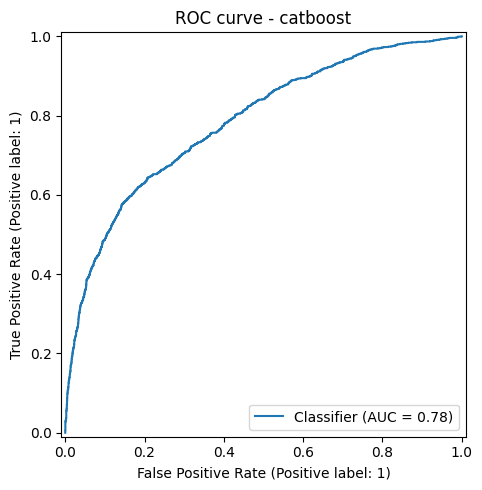

<Figure size 600x600 with 0 Axes>

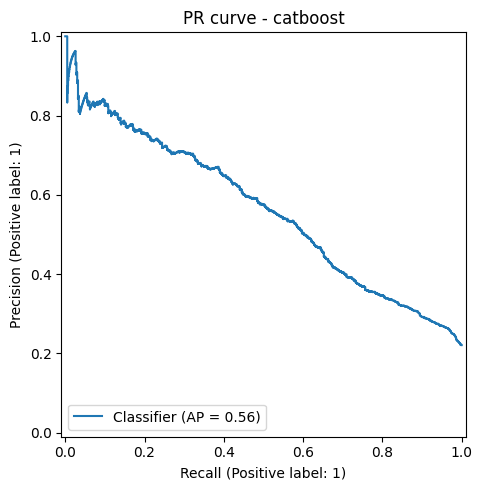

<Figure size 600x600 with 0 Axes>

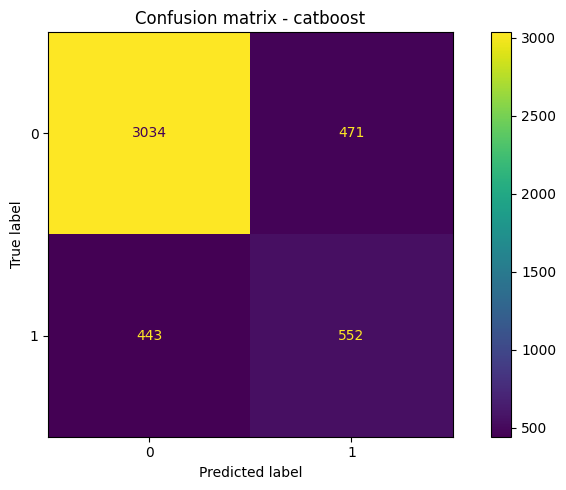

In [18]:
catboost_threshold = find_best_threshold(y_train_full, best_oof_proba)
print("CatBoost OOF threshold:", round(catboost_threshold, 6))

best_model = CatBoostClassifier(
    **best_params,
    auto_class_weights="Balanced",
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=RANDOM_STATE,
    thread_count=-1,
    verbose=100,
)

best_model.fit(
    X_train_full_cb,
    y_train_full,
    cat_features=categorical_features,
)

catboost_test_proba = best_model.predict_proba(X_test_cb)[:, 1]
catboost_test_metrics = calculate_metrics(y_test, catboost_test_proba, catboost_threshold)

best_model.save_model(MODELS_DIR / "catboost_credit_scoring.cbm")

catboost_artifacts = {
    "feature_names": list(X_train_full_cb.columns),
    "categorical_features": categorical_features,
    "threshold": float(catboost_threshold),
    "best_params": best_params,
    "cv_best_pr_auc": float(best_cv_pr_auc),
}

(MODELS_DIR / "catboost_artifacts.json").write_text(
    json.dumps(catboost_artifacts, indent=4, ensure_ascii=False),
    encoding="utf-8",
)

print("CatBoost test metrics:")
print(json.dumps(catboost_test_metrics, indent=4, ensure_ascii=False))

save_eval_plots(y_test, catboost_test_proba, catboost_threshold, "catboost")

## 8. Feature importance

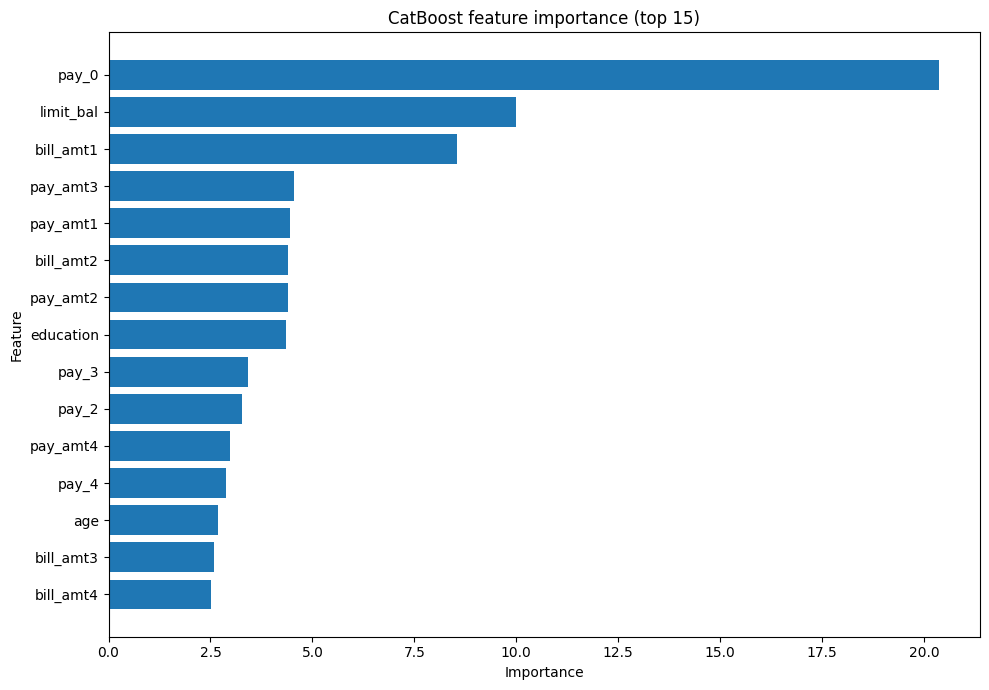

,feature,importance
5,pay_0,20.353374
0,limit_bal,9.984661
11,bill_amt1,8.549259
19,pay_amt3,4.547923
17,pay_amt1,4.438743
12,bill_amt2,4.406007
18,pay_amt2,4.396305
2,education,4.344467
7,pay_3,3.420553
6,pay_2,3.281668


In [19]:
feature_importance = pd.DataFrame(
    {
        "feature": X_train_full_cb.columns,
        "importance": best_model.get_feature_importance(),
    }
).sort_values(by="importance", ascending=False)

feature_importance.to_csv(METRICS_DIR / "catboost_feature_importance.csv", index=False)

top_features = feature_importance.head(15).sort_values(by="importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("CatBoost feature importance (top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "catboost_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

display(feature_importance.head(15))

## 9. Итоговое сравнение моделей

In [20]:
all_metrics = {
    "baseline": {
        "cv_summary": baseline_cv_summary,
        "test_metrics": baseline_test_metrics,
    },
    "catboost": {
        "best_params": best_params,
        "cv_best_pr_auc": best_cv_pr_auc,
        "test_metrics": catboost_test_metrics,
    },
}

(METRICS_DIR / "model_metrics.json").write_text(
    json.dumps(all_metrics, indent=4, ensure_ascii=False),
    encoding="utf-8",
)

comparison_df = pd.DataFrame(
    [
        {"model": "baseline", **baseline_test_metrics},
        {"model": "catboost", **catboost_test_metrics},
    ]
).sort_values(by=["pr_auc", "roc_auc"], ascending=False)

comparison_df.to_csv(METRICS_DIR / "model_comparison.csv", index=False)

display(comparison_df)

,model,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
1,catboost,0.560524,0.796889,0.783944,0.561913,0.539589,0.554774,0.547076,3034,471,443,552
0,baseline,0.588107,0.794444,0.712214,0.498528,0.542271,0.451256,0.492595,3126,379,546,449
